# Archetype analysis on Harmony data: comparing K

In [1]:
import scanpy as sc
import scvelo as scv
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os.path as op
import sys
sys.path.insert(1, "/Users/smgroves/Documents/GitHub/multiome-analysis/archetype-plasticity-notebooks/")
from py_pcha_patched import PCHA
from scipy.spatial.distance import squareform
from scipy.spatial.distance import pdist


In [2]:
adata = sc.read_h5ad('../../data/combined/adata_02_filtered.h5ad')

In [3]:
x_harmony = pd.read_csv('./ParetoTI/x_harmony2.csv', index_col = 0)

In [4]:
adata.obsm['X_pca'].shape

(8908, 50)

In [5]:
x_harmony = x_harmony.T
harmony_indices = []
for i, r in adata.obs.iterrows():
    adata_label = i.split(':')[1][:-4]+"-" + i.split("-")[1][1]
    if adata_label in x_harmony.index:
        harmony_indices.append(adata_label)
        
x_harmony = x_harmony.loc[harmony_indices]
adata.obsm['X_harmony2'] = np.array(x_harmony)

In [6]:
def find_knee(ev_per_arc, kmax):
    farthestk = 0
    for i in range(3,kmax):
        #find distance of point p3 from line between p1 and p2
        p1=np.array([3,ev_per_arc[0]])
        p2=np.array([kmax,ev_per_arc[kmax-3]])
        p3=np.array([i,ev_per_arc[i-3]])
        k = (np.cross(p2-p1,p3-p1)/np.linalg.norm(p2-p1))

        #knee is farthest away from line between p1 and p2
        if k > farthestk: 
            farthestk = k
            knee = i
    print("K* =",knee, "archetypes, distance between k* and line: ",np.round(farthestk,2))
    return knee, farthestk

In [106]:
ev_per_arc_ = []
for i in range(2,11):
    XC, S, C, SSE, varexpl = PCHA(adata.obsm['X_harmony2'].T, noc=i, delta=0.1)
    ev_per_arc_.append(varexpl)
    print(f"{i} vertices: ",varexpl)

2 vertices:  0.35424480325051205
3 vertices:  0.40559313871521474
4 vertices:  0.4444792727915876
5 vertices:  0.4688544601504452
6 vertices:  0.506571534293087
7 vertices:  0.53476187858507
8 vertices:  0.5568233702744381
9 vertices:  0.5755612959747138
10 vertices:  0.5922789869423628


In [95]:
ev_per_arc = []
for i in range(2,11):
    XC, S, C, SSE, varexpl = PCHA(adata.obsm['X_harmony2'][:, 0:10].T, noc=i, delta=0.1)
    ev_per_arc.append(varexpl)
    print(f"{i} vertices: ",varexpl)

0.5953367767742156
0.683011759144852
0.75060301181056
0.8008395930854517
0.8579522718444924
0.905317062558866
0.933937574045635
0.9661597628663596
0.9718446782506082


In [96]:
!pip install kneed

In [107]:
from kneed import KneeLocator

k_values = np.arange(2, 11)

kneedle = KneeLocator(
    k_values, 
    ev_per_arc_, 
    curve='concave',      # Use 'concave' if variance explained increases and levels off
    direction='increasing'  # Variance explained increases with k
)

knee = kneedle.knee
print(f"K* = {knee} archetypes (using kneed library)")


K* = 6 archetypes (using kneed library)


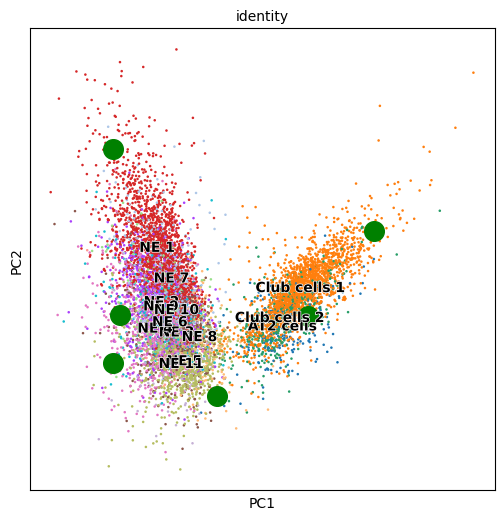

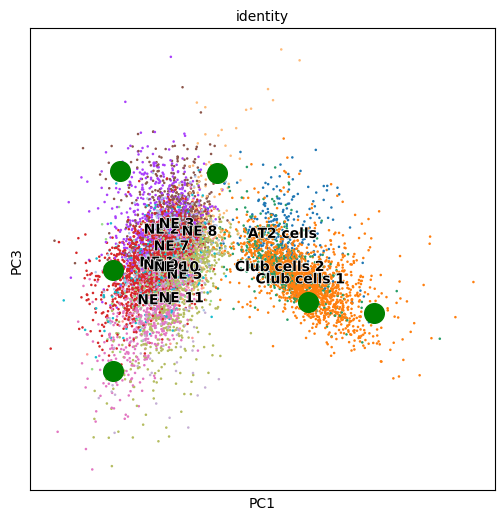

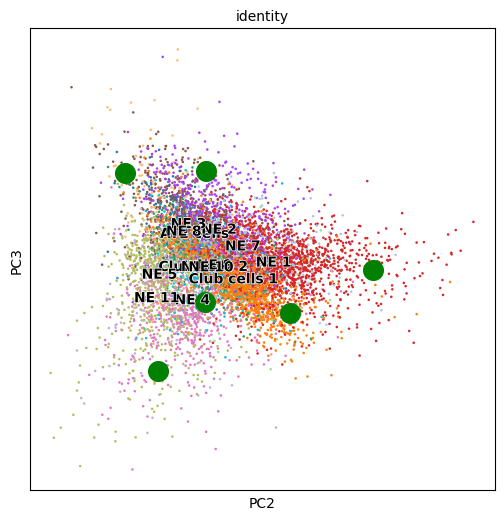

In [148]:
XC, S, C, SSE, varexpl = PCHA(adata.obsm['X_harmony2'].T, noc=6, delta=0)
XC = np.array(XC)
for components in ['1,2','1,3','2,3']:
    scv.pl.scatter(adata, color = 'identity', basis = 'harmony2', components=components, show=False, figsize= (6,6), frameon=True)
    comp = components.split(',')
    plt.scatter(XC[int(comp[0])-1], XC[int(comp[1])-1], color = 'green', s = 200)
    plt.xlabel("PC"+comp[0])
    plt.ylabel("PC"+comp[1])

    plt.show()

In [10]:
adata

AnnData object with n_obs × n_vars = 8908 × 16719
    obs: 'dropkick_score', 'dropkick_label', 'arcsinh_n_genes_by_counts', 'sample_x', 'initial_size_spliced', 'initial_size_unspliced', 'initial_size', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_ambient', 'log1p_total_counts_ambient', 'pct_counts_ambient', 'arcsinh_total_counts', 'S_score', 'G2M_score', 'phase', 'brcd', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'barcode', 'sample_y', 'ATAC_snn_res.0.5', 'seurat_clusters', 'nCount_peaks', 'nFeature_peaks', 'peaks_snn_res.0.5', 'percent.mt', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.5', 'SCT.weight', 'peaks.weight', 'nCount_Imputed_counts', 'nFeature_Imputed_counts', 'nCount_gene_activity', 'nFeature_gene_activity', 'NE_score1', 'identity', 'non.NE_s

In [149]:
S_df = pd.DataFrame(S.T)

In [150]:
S_df.index = adata.obs_names
S_df.columns = ['Arc_1','Arc_2','Arc_3','Arc_4','Arc_5', 'Arc_6']

In [151]:
max_arc = (S_df > .5).idxmax(axis=1)

In [152]:
for i,r in S_df.iterrows():
    if r.max() < 0.5:
        max_arc[i] = 'Generalist'

In [153]:
adata.obs['S_0.5threshold_50dims'] = max_arc
#make S_0.5threshold_50dims a categorical variable
adata.obs["S_0.5threshold_50dims"] =  pd.Categorical(adata.obs['S_0.5threshold_50dims'])


In [11]:
adata.uns['archetype_locations'] = XC

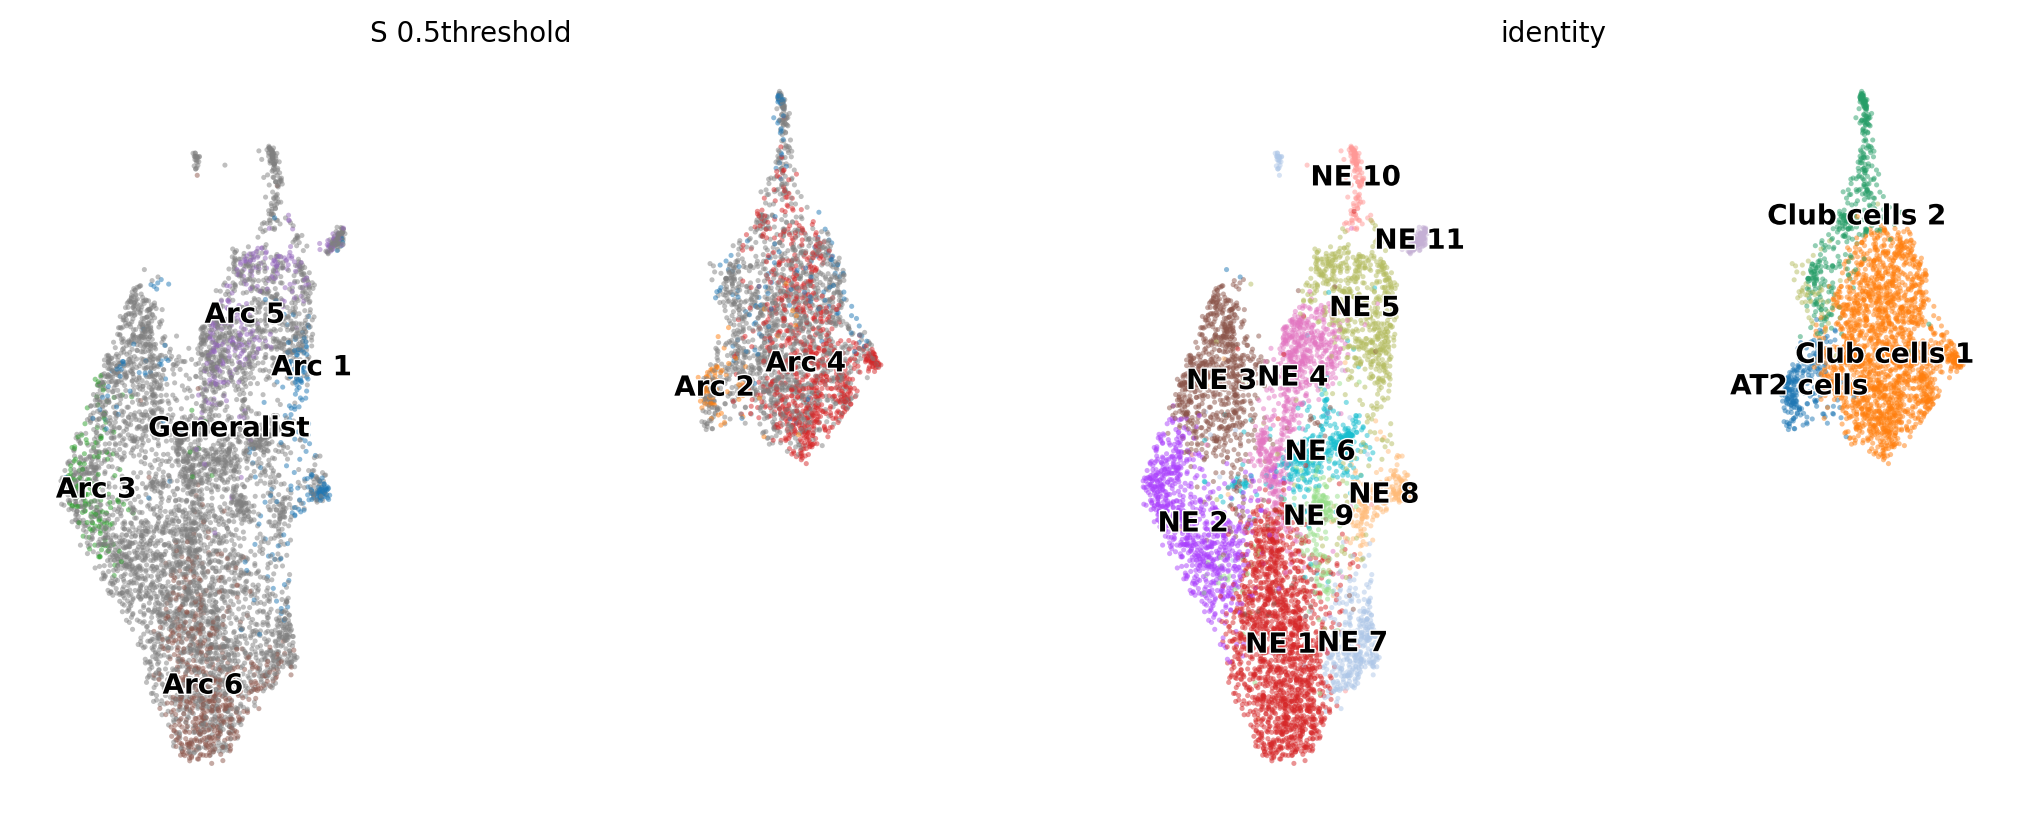

In [131]:
scv.pl.scatter(adata, basis = 'umap_wnn', color = ['S_0.5threshold','identity'], legend_loc = 'on data',dpi = 200, alpha = .5)

In [14]:
adata.obs

,dropkick_score,dropkick_label,arcsinh_n_genes_by_counts,sample_x,initial_size_spliced,initial_size_unspliced,initial_size,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,...,Arc_3_PCHA_Score,Arc_4_PCHA_Score,Arc_5_PCHA_Score,Arc_6_PCHA_Score,S_0.5threshold,S_0.6threshold,archetype_label,er_genes,bad_fit_genes,NE
CellID,,,,,,,,,,,,,,,,,,,,,
gex_possorted_bam_SJSO3:AAACCGGCAGCCTAACx-M1,0.190799,False,6.419998,M1,603,815,603.0,307,5.730100,255.714691,...,0.101080,0.073335,0.239396,0.343649,Generalist,Generalist,Generalist,0.144596,0.136481,NE
gex_possorted_bam_SJSO3:AAAGCCGCACCCACCTx-M1,0.270716,False,6.458341,M1,693,1079,693.0,319,5.768321,244.293030,...,0.098842,0.008717,0.297490,0.347048,Generalist,Generalist,Generalist,0.068858,-0.079841,NE
gex_possorted_bam_SJSO3:AAACGTACAGGACCAAx-M1,0.323707,False,6.100324,M1,487,551,487.0,223,5.411646,219.160767,...,0.032418,0.467110,0.126746,0.028924,Generalist,Generalist,Generalist,0.185072,0.356662,non_NE
gex_possorted_bam_SJSO3:AAAGGACGTAACGAGGx-M1,0.193199,False,5.521477,M1,216,400,216.0,125,4.836282,187.980469,...,0.142250,0.000000,0.352118,0.147424,Generalist,Generalist,Generalist,-0.024306,-0.061175,NE
gex_possorted_bam_SJSO3:AAACATGCAATGAAGCx-M1,0.268449,False,6.342125,M1,608,1009,608.0,284,5.652489,239.517517,...,0.566935,0.065554,0.036348,0.191672,Arc_3,Generalist,Arc_3,0.039790,-0.090951,NE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
gex_possorted_bam_1WGCZ:TTTGTGTTCCTTAGGGx-M2,0.000000,False,6.396932,M2,435,404,435.0,300,5.707110,305.394867,...,0.114562,0.000000,0.072423,0.000000,Generalist,Generalist,Generalist,0.190809,0.398137,NE
gex_possorted_bam_1WGCZ:TTTGTGGCATGGCCCAx-M2,0.377218,False,7.213769,M2,957,1898,957.0,679,6.522093,406.367523,...,0.335363,0.020848,0.045008,0.183252,Generalist,Generalist,Generalist,0.000479,0.024657,NE
gex_possorted_bam_1WGCZ:TTTGTGTTCGGCCATAx-M2,0.336164,False,7.054450,M2,785,4144,785.0,579,6.363028,398.740112,...,0.116906,0.000000,0.124757,0.437688,Generalist,Generalist,Generalist,0.143608,0.319564,NE


In [31]:
#double check these labels match what Debbie is using
debbie_labels = pd.read_csv('../../data/combined/final_labels.csv',
                            index_col=0)
#AAACAGCCACAGGGAC-2 in debbie_labels is gex_possorted_bam_SJSO3:AAACAGCCACAGGGACx-M1 in adata, so we need to shorten the adata name when we match them up
#get this form for both and then add TKO_final_arc.active.ident from debbie_labels to adata.obs
adata.obs['debbie_labels'] = adata.obs_names.map(lambda x: x.split(':')[1][:-4]+"-"+x.split("-")[1][1]).map(debbie_labels['TKO_final_arc.active.ident'])

#make debbie_labels categorical and order them in the same way as identity
adata.obs['debbie_labels'] = pd.Categorical(adata.obs['debbie_labels'])



In [37]:
adata.obs[['S_0.5threshold','debbie_labels']]

,S_0.5threshold,debbie_labels
CellID,,
gex_possorted_bam_SJSO3:AAACCGGCAGCCTAACx-M1,Generalist,Generalist NE
gex_possorted_bam_SJSO3:AAAGCCGCACCCACCTx-M1,Generalist,Generalist NE
gex_possorted_bam_SJSO3:AAACGTACAGGACCAAx-M1,Generalist,Generalist nonNE
gex_possorted_bam_SJSO3:AAAGGACGTAACGAGGx-M1,Generalist,Generalist NE
gex_possorted_bam_SJSO3:AAACATGCAATGAAGCx-M1,Arc_3,Stress
...,...,...
gex_possorted_bam_1WGCZ:TTTGTGTTCCTTAGGGx-M2,Generalist,Generalist NE
gex_possorted_bam_1WGCZ:TTTGTGGCATGGCCCAx-M2,Generalist,Generalist NE
gex_possorted_bam_1WGCZ:TTTGTGTTCGGCCATAx-M2,Generalist,Generalist NE


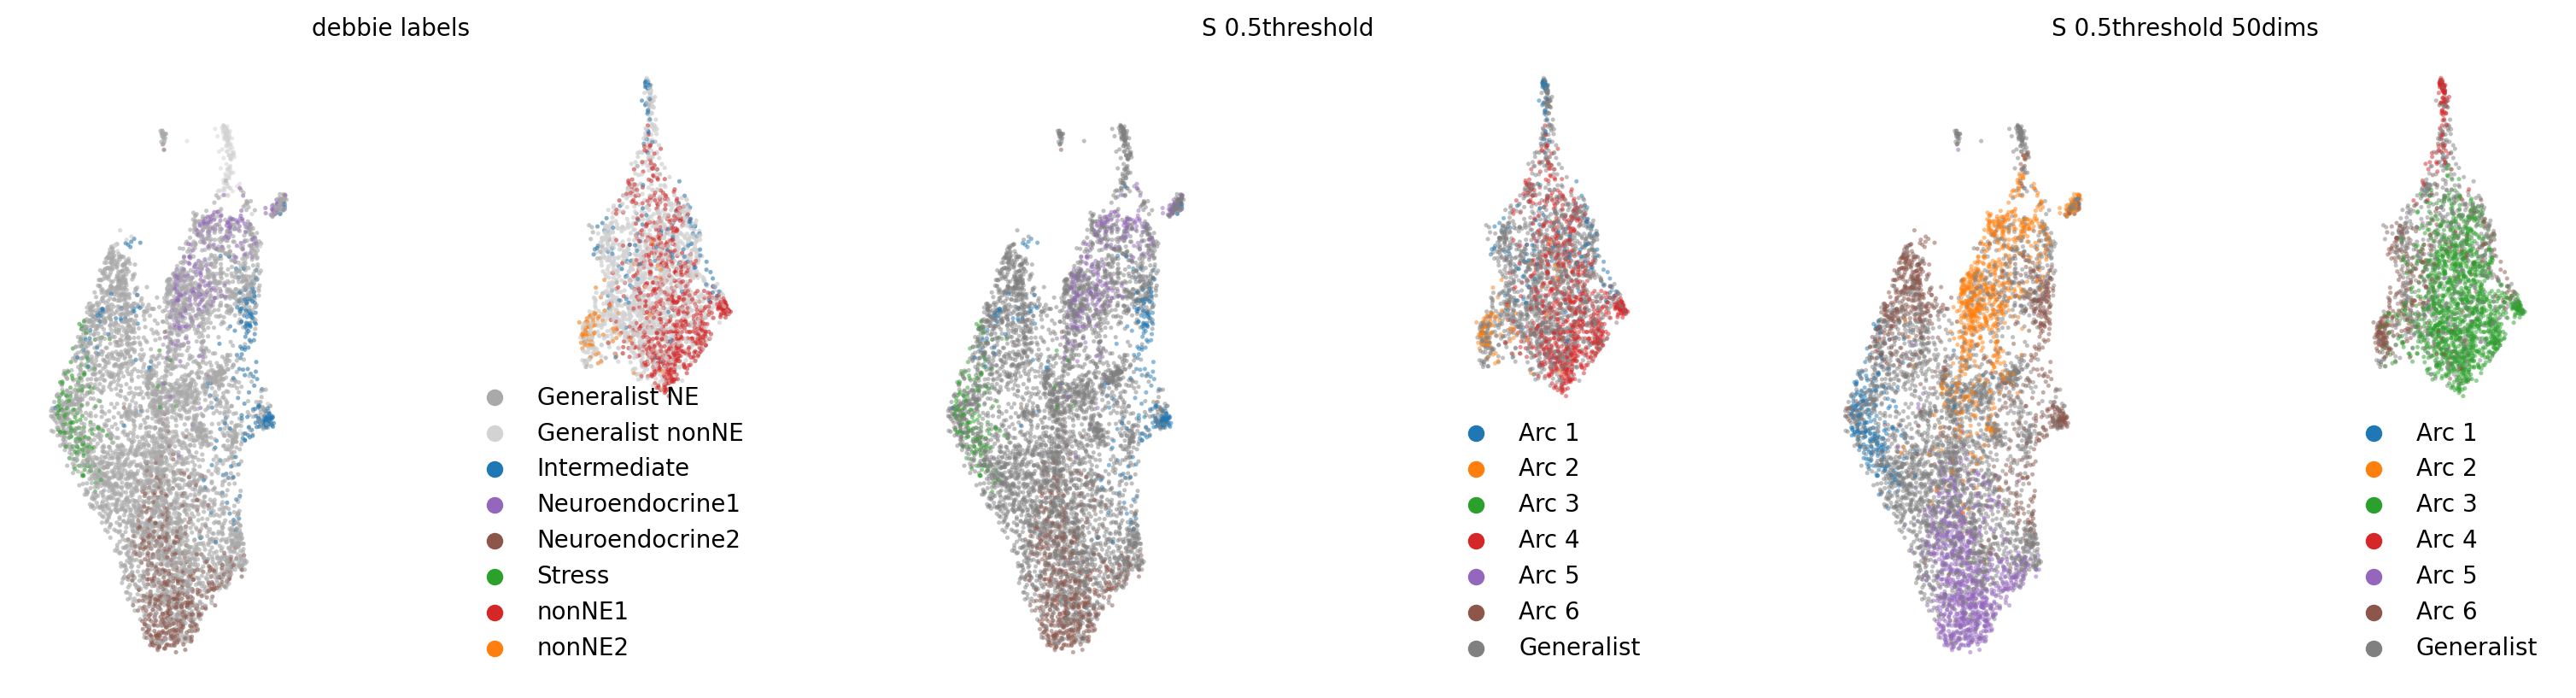

In [154]:
# Generalist is grey, Generalist NE is dark grey, Generalist nonNE is light grey
#match up archetype colors based on S_0.5threshold compared to debbie_labels in adata.obs

archetype_colors = {
    'Generalist': 'grey',
    'Arc_1': '#1f77b4', #blue
    'Arc_2': '#ff7f0e', #orange
    'Arc_3': '#2ca02c', #green
    'Arc_4': '#d62728', #red
    'Arc_5': '#9467bd', #purple
    'Arc_6': '#8c564b' #brown
}

debbie_colors = {
    'Generalist': 'grey',
    'Generalist NE': 'darkgrey',
    'Generalist nonNE': 'lightgrey',
    'Intermediate': archetype_colors['Arc_1'],
    'nonNE2': archetype_colors['Arc_2'],
    'Stress': archetype_colors['Arc_3'],
    'nonNE1': archetype_colors['Arc_4'],
    'Neuroendocrine1': archetype_colors['Arc_5'],
    'Neuroendocrine2': archetype_colors['Arc_6']
}


adata.uns['debbie_labels_colors'] = debbie_colors
adata.uns['S_0.5threshold_colors'] = archetype_colors
adata.uns['S_0.5threshold_50dims_colors'] = archetype_colors

scv.pl.scatter(adata,
               basis='umap_wnn',
               color=[ 'debbie_labels', 'S_0.5threshold', 'S_0.5threshold_50dims'],
               legend_loc='best',
               dpi=200,
               alpha=.5)

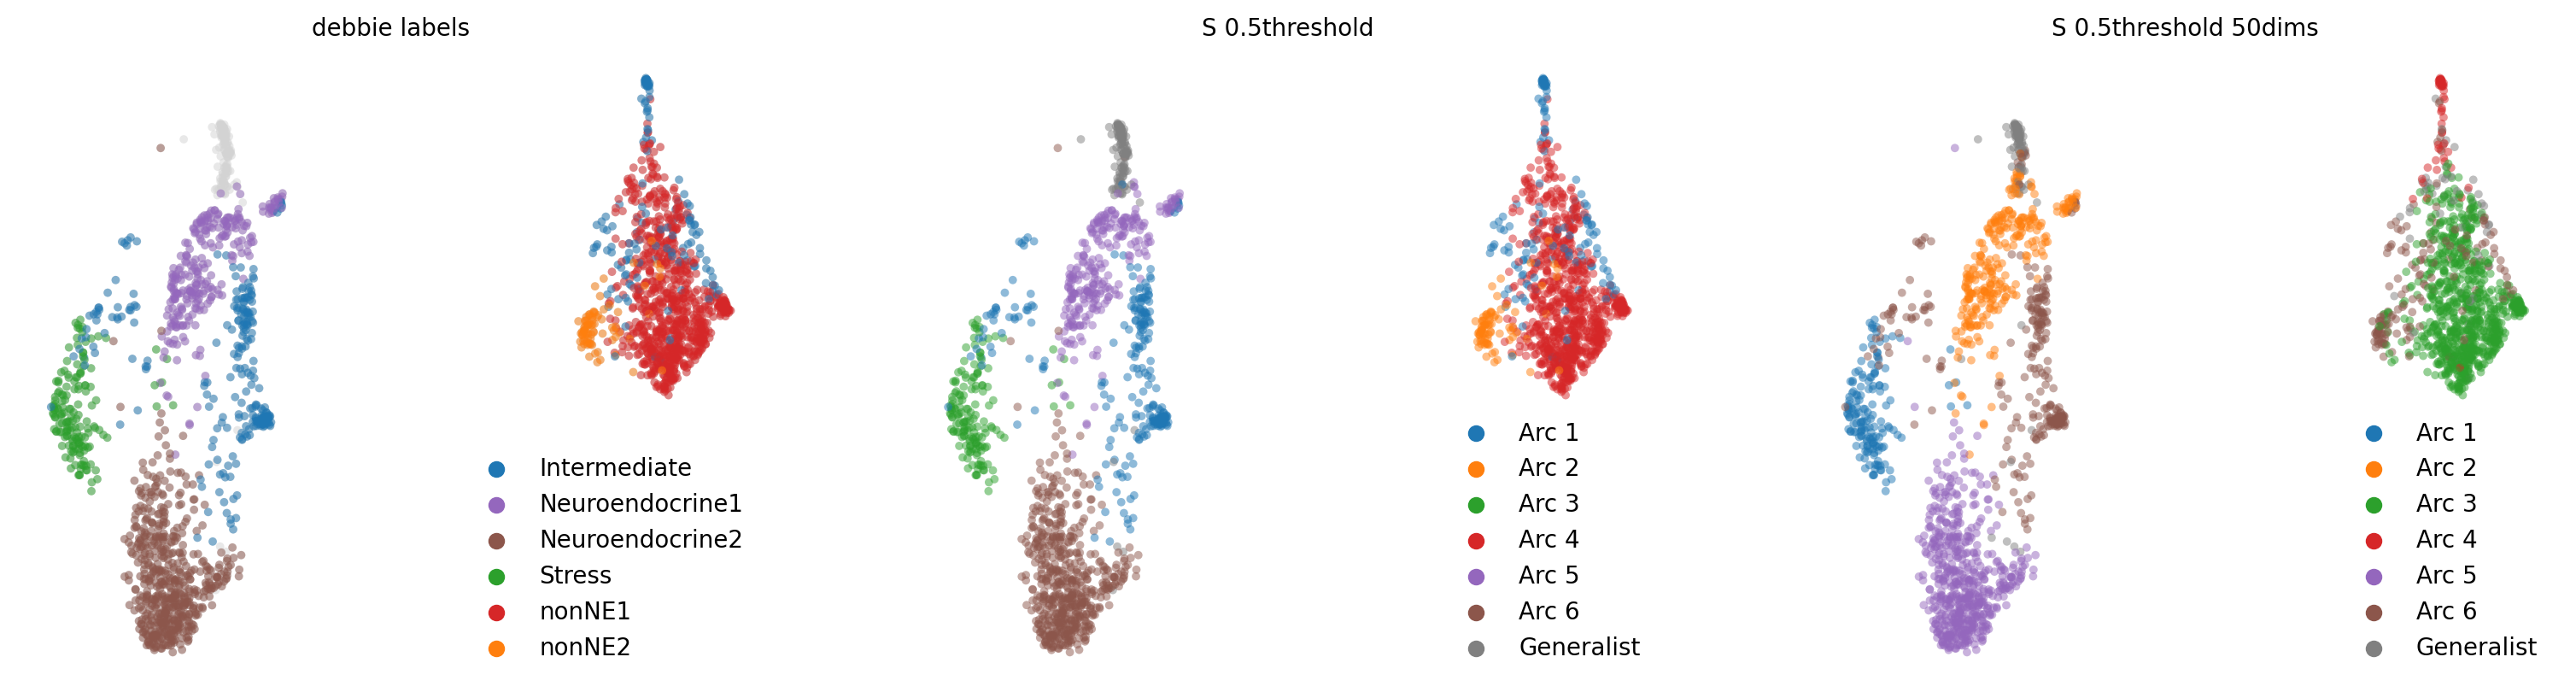

In [155]:
#dont plot generalists
adata_no_generalists = adata[~adata.obs['debbie_labels'].isin(['Generalist', 'Generalist NE', 'Generalist nonNE'])]
scv.pl.scatter(adata_no_generalists,
               basis='umap_wnn',
               color=[ 'debbie_labels', 'S_0.5threshold','S_0.5threshold_50dims'],
               legend_loc='best',
               dpi=200,
               alpha=.5)

In [156]:
#crosstable
# !pip install jinja2
pd.crosstab(adata.obs['S_0.5threshold_50dims'],adata.obs['debbie_labels']).style.background_gradient(cmap='viridis').format(precision=0)



debbie_labels,Generalist NE,Generalist nonNE,Intermediate,Neuroendocrine1,Neuroendocrine2,Stress,nonNE1,nonNE2
S_0.5threshold_50dims,,,,,,,,
Arc_1,77,0,0,0,0,162,0,0
Arc_2,589,0,0,267,2,0,0,0
Arc_3,2,660,2,0,0,0,773,21
Arc_4,0,52,27,0,0,0,23,0
Arc_5,390,1,0,0,571,0,0,0
Arc_6,555,191,334,0,0,0,0,57
Generalist,3289,682,22,0,0,1,26,3


## Try different numbers of archetypes to see if intermediate state is still found

In [108]:
adata_pca_df = pd.DataFrame(adata.obsm['X_harmony2'], index = adata.obs_names)

for i in range(3, 10):
    XC, S, C, SSE, varexpl = PCHA(adata.obsm['X_harmony2'].T, noc=i, delta=0.1)
    # S matrix labeling
    print(f"Processing k={i} archetypes, EV explained: {varexpl}")
    S_df = pd.DataFrame(S.T)
    S_df.index = adata.obs_names
    adata.obsm[f'S_{i}'] = S_df
    max_arc = (S_df > .5).idxmax(axis=1)
    for j,r in S_df.iterrows():
        if r.max() < 0.5:
            max_arc[j] = 'Generalist'
    adata.obs[f'S_0.5threshold_{i}'] = max_arc
    # distance to archetype
    print(f"Calculating distances to archetypes for k={i}...")
    XC_df = pd.DataFrame(XC)
    adata.uns[f'XC_{i}'] = XC_df.T
    #append to bottom of adata_pca_df and then compute distances to archetypes on pca space
    adata_full_df = pd.concat([adata_pca_df, XC_df.T], axis = 0)
    pdx = squareform(pdist(adata_full_df, metric='euclidean')) # compute distances on pca
    pdx_df = pd.DataFrame(pdx, index=adata_full_df.index, columns=adata_full_df.index)
    pdx_df = pdx_df.loc[XC_df.columns].drop(XC_df.columns, axis = 1)
    adata.obsm[f'arc_distance_{i}'] = pdx_df.T


Processing k=3 archetypes, EV explained: 0.4055940023388531
Calculating distances to archetypes for k=3...
Processing k=4 archetypes, EV explained: 0.44448012858406843
Calculating distances to archetypes for k=4...
Processing k=5 archetypes, EV explained: 0.46885763807243314
Calculating distances to archetypes for k=5...
Processing k=6 archetypes, EV explained: 0.5065713035194078
Calculating distances to archetypes for k=6...
Processing k=7 archetypes, EV explained: 0.5347623793816515
Calculating distances to archetypes for k=7...
Processing k=8 archetypes, EV explained: 0.5568232406271797
Calculating distances to archetypes for k=8...
Processing k=9 archetypes, EV explained: 0.5755614573362707
Calculating distances to archetypes for k=9...


Correlation between archetypes for k=3 and k=6:
[[ 0.37009609 -0.35645062 -0.13924678 -0.08808709  0.84492776 -0.35153997]
 [ 0.37330944 -0.77080704  0.76288493 -0.47515403 -0.53378247  0.86868529]
 [-0.56157638  0.98254019 -0.69135093  0.51881821  0.03086339 -0.64661691]]
Correlation between archetypes for k=4 and k=6:
[[-0.55488873  0.98388518 -0.68952211  0.51872511  0.01512974 -0.63833875]
 [ 0.31530168 -0.28123839 -0.27050907 -0.0684367   0.89016924 -0.34726591]
 [ 0.41873577 -0.64631173  0.38925063 -0.4238557  -0.47536835  0.97332816]
 [ 0.22412998 -0.67325677  0.9985572  -0.35685427 -0.39747047  0.37479236]]
Correlation between archetypes for k=5 and k=6:
[[ 0.26765302 -0.74003714  0.77650059 -0.46588275 -0.53784352  0.86662331]
 [ 0.99607765 -0.50111663  0.20045241 -0.31164463 -0.13479489  0.25413365]
 [-0.09341424 -0.14927932 -0.23250334 -0.05132994  0.97278994 -0.45164133]
 [-0.50564689  0.99935387 -0.67470822  0.36876396 -0.02225405 -0.60244525]
 [-0.31334088  0.39096319 -0.

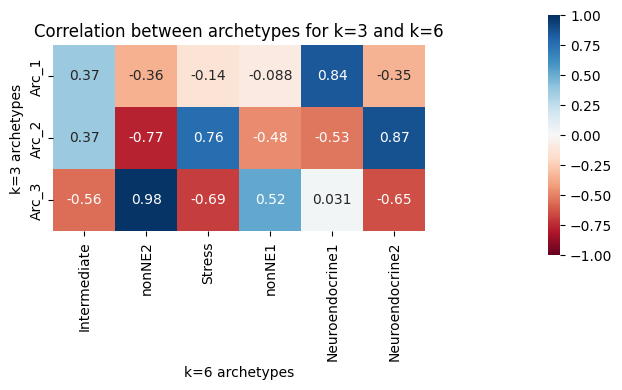

Optimal matching for k=3:
  Arc_1 (k=3) ↔ Neuroendocrine1 (k=6): corr = 0.845
  Arc_2 (k=3) ↔ Neuroendocrine2 (k=6): corr = 0.869
  Arc_3 (k=3) ↔ nonNE2 (k=6): corr = 0.983


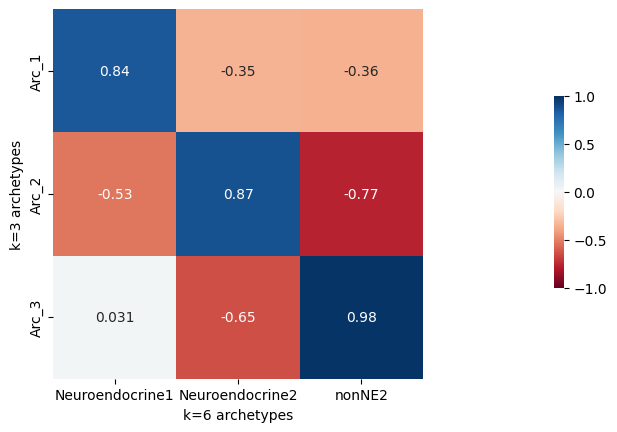

(4, 50) (6, 50)


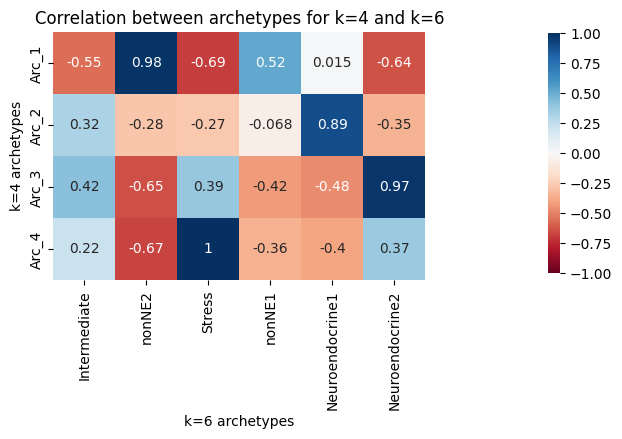

Optimal matching for k=4:
  Arc_1 (k=4) ↔ nonNE2 (k=6): corr = 0.984
  Arc_2 (k=4) ↔ Neuroendocrine1 (k=6): corr = 0.890
  Arc_3 (k=4) ↔ Neuroendocrine2 (k=6): corr = 0.973
  Arc_4 (k=4) ↔ Stress (k=6): corr = 0.999


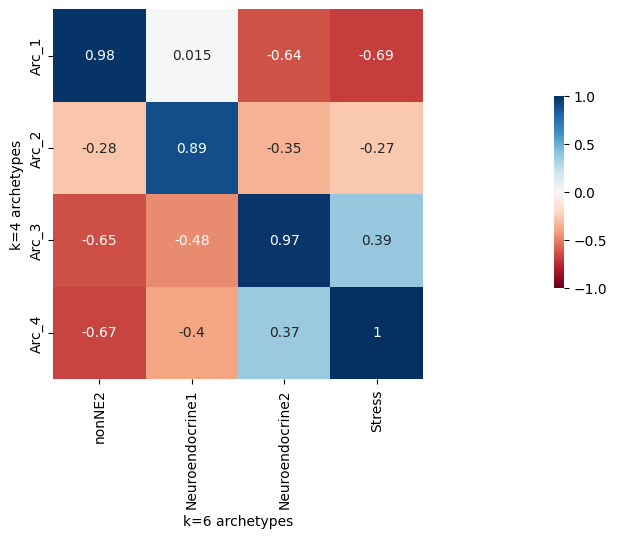

(5, 50) (6, 50)


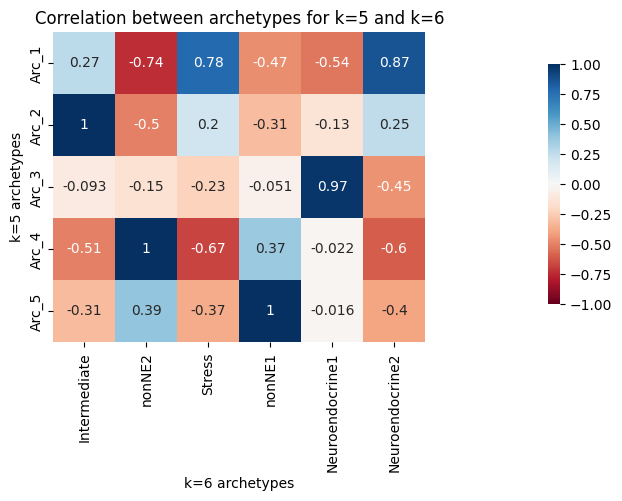

Optimal matching for k=5:
  Arc_1 (k=5) ↔ Neuroendocrine2 (k=6): corr = 0.867
  Arc_2 (k=5) ↔ Intermediate (k=6): corr = 0.996
  Arc_3 (k=5) ↔ Neuroendocrine1 (k=6): corr = 0.973
  Arc_4 (k=5) ↔ nonNE2 (k=6): corr = 0.999
  Arc_5 (k=5) ↔ nonNE1 (k=6): corr = 0.998


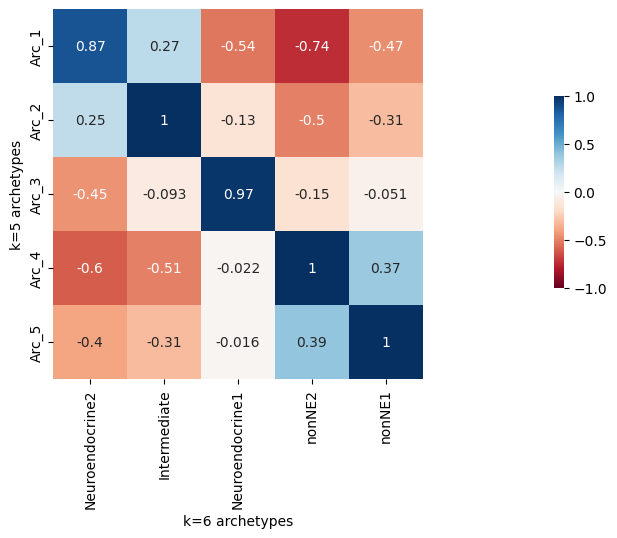

(6, 50) (6, 50)


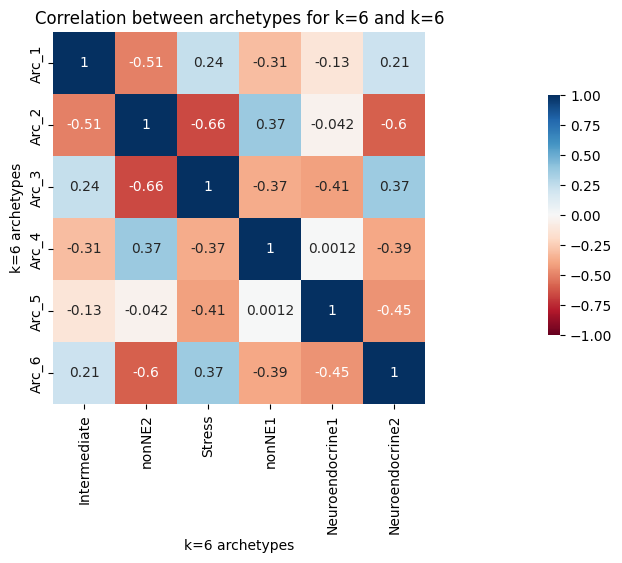

Optimal matching for k=6:
  Arc_1 (k=6) ↔ Intermediate (k=6): corr = 1.000
  Arc_2 (k=6) ↔ nonNE2 (k=6): corr = 1.000
  Arc_3 (k=6) ↔ Stress (k=6): corr = 1.000
  Arc_4 (k=6) ↔ nonNE1 (k=6): corr = 1.000
  Arc_5 (k=6) ↔ Neuroendocrine1 (k=6): corr = 1.000
  Arc_6 (k=6) ↔ Neuroendocrine2 (k=6): corr = 1.000


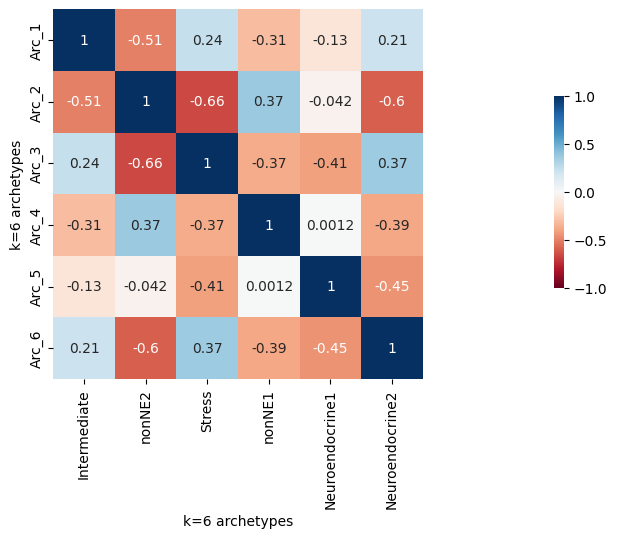

(7, 50) (6, 50)


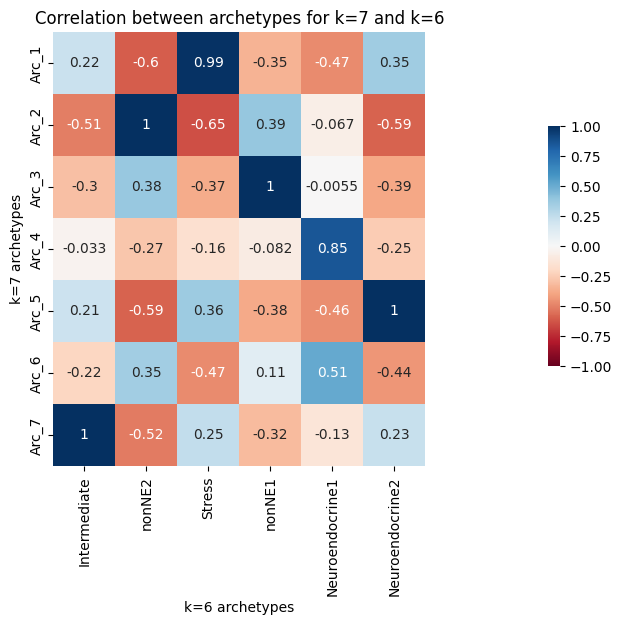

Optimal matching for k=7:
  Arc_1 (k=7) ↔ Stress (k=6): corr = 0.991
  Arc_2 (k=7) ↔ nonNE2 (k=6): corr = 0.996
  Arc_3 (k=7) ↔ nonNE1 (k=6): corr = 0.998
  Arc_4 (k=7) ↔ Neuroendocrine1 (k=6): corr = 0.853
  Arc_5 (k=7) ↔ Neuroendocrine2 (k=6): corr = 0.999
  Arc_7 (k=7) ↔ Intermediate (k=6): corr = 0.999


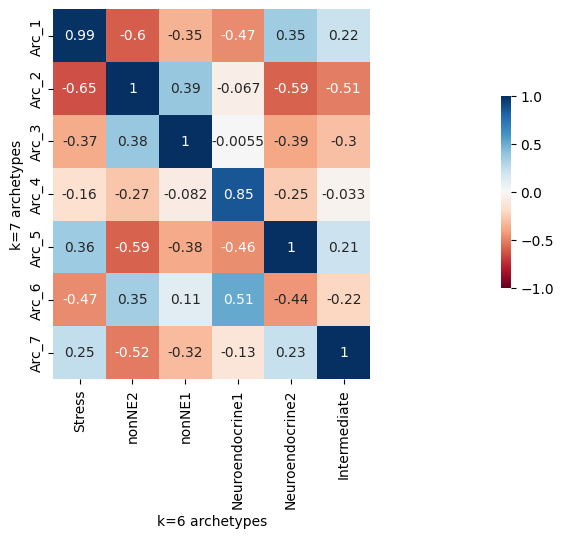

(8, 50) (6, 50)


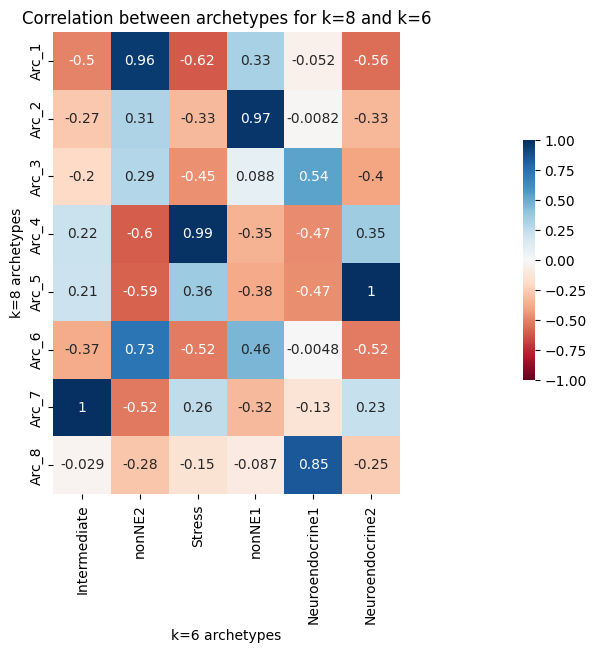

Optimal matching for k=8:
  Arc_1 (k=8) ↔ nonNE2 (k=6): corr = 0.958
  Arc_2 (k=8) ↔ nonNE1 (k=6): corr = 0.971
  Arc_4 (k=8) ↔ Stress (k=6): corr = 0.991
  Arc_5 (k=8) ↔ Neuroendocrine2 (k=6): corr = 0.999
  Arc_7 (k=8) ↔ Intermediate (k=6): corr = 0.999
  Arc_8 (k=8) ↔ Neuroendocrine1 (k=6): corr = 0.849


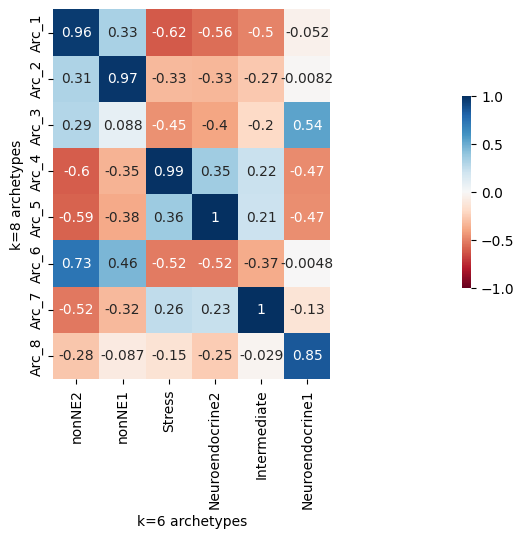

In [109]:
from scipy.optimize import linear_sum_assignment

#correlation between archetypes across different k
for i in range(3, 9):
    print(f"Correlation between archetypes for k={i} and k=6:")
    print(np.corrcoef(adata.uns[f'XC_{i}'], adata.uns[f'XC_6'])[:i, i:])

arc_6_labels = ['Intermediate', 'nonNE2', 'Stress', 'nonNE1', 'Neuroendocrine1', 'Neuroendocrine2']
for i in range(3, 9):
    plt.figure(figsize=(6,6))
    plt.title(f"Correlation between archetypes for k={i} and k=6")
    #show numbers on heatmap
    print(adata.uns[f'XC_{i}'].shape, adata.uns[f'XC_6'].shape)
    corr_mat = np.corrcoef(adata.uns[f'XC_{i}'], adata.uns[f'XC_6'])[:i, i:]
    sns.heatmap(corr_mat, 
                square=True,
                annot=True, cmap='RdBu', vmin=-1, vmax=1, xticklabels=arc_6_labels, yticklabels=[f'Arc_{x+1}' for x in range(i)])
    #make colorbar smaller
    cbar = plt.gcf().axes[-1]
    cbar.set_position([0.95, 0.3, 0.02, 0.4])
    plt.xlabel(f"k=6 archetypes")
    plt.ylabel(f"k={i} archetypes")
    plt.savefig(f'./figures/correlation_XC_arc_location_k_{i}_k_6_full_10PCs.png')
    plt.show()
    plt.close() 
    #reorder axes in corr_mat so that highest correlation in on diagonal

    # Find optimal matching (maximize correlation = minimize negative correlation)
    row_ind, col_ind = linear_sum_assignment(-corr_mat)

    # Reorder columns to align with rows
    corr_mat_reordered = corr_mat[:, col_ind]

    # Also reorder the labels
    arc_6_labels_reordered = [arc_6_labels[j] for j in col_ind]

    print(f"Optimal matching for k={i}:")
    for r, c in zip(row_ind, col_ind):
        print(f"  Arc_{r+1} (k={i}) ↔ {arc_6_labels[c]} (k=6): corr = {corr_mat[r, c]:.3f}")

    sns.heatmap(corr_mat_reordered, 
                square=True,
                annot=True, cmap='RdBu', vmin=-1, vmax=1, xticklabels=arc_6_labels_reordered, yticklabels=[f'Arc_{x+1}' for x in range(i)])
    #make colorbar smaller
    cbar = plt.gcf().axes[-1]
    cbar.set_position([0.95, 0.3, 0.02, 0.4])
    plt.xlabel(f"k=6 archetypes")
    plt.ylabel(f"k={i} archetypes")
    plt.savefig(f'./figures/correlation_XC_arc_location_k_{i}_k_6_matched_10PCs.png')
    plt.show()
        

In [111]:
#calculate 6 archetypes with different random seeds and see how consistent they are
for seed in [42, 0, 1, 2, 3, 4]:
    np.random.seed(seed)
    XC, S, C, SSE, varexpl = PCHA(adata.obsm['X_harmony2'].T, noc=6, delta=0.1)
    XC = np.array(XC)
    adata.uns[f'XC_6_seed_{seed}'] = XC.T
    print(f"Correlation between archetypes for k=6 with seed {seed} and seed 42:")
    print(np.corrcoef(adata.uns[f'XC_6_seed_{seed}'], adata.uns[f'XC_6_seed_42'])[:6, 6:])

Correlation between archetypes for k=6 with seed 42 and seed 42:
[[ 1.00000000e+00  2.40189327e-01 -5.06624278e-01 -3.09630700e-01
   2.11067644e-01 -1.27900512e-01]
 [ 2.40189327e-01  1.00000000e+00 -6.60891329e-01 -3.72730122e-01
   3.66645627e-01 -4.10833212e-01]
 [-5.06624278e-01 -6.60891329e-01  1.00000000e+00  3.74765839e-01
  -6.01275698e-01 -4.29466463e-02]
 [-3.09630700e-01 -3.72730122e-01  3.74765839e-01  1.00000000e+00
  -3.86752754e-01  8.66750719e-04]
 [ 2.11067644e-01  3.66645627e-01 -6.01275698e-01 -3.86752754e-01
   1.00000000e+00 -4.47181333e-01]
 [-1.27900512e-01 -4.10833212e-01 -4.29466463e-02  8.66750719e-04
  -4.47181333e-01  1.00000000e+00]]
Correlation between archetypes for k=6 with seed 0 and seed 42:
[[ 0.9999999   0.24019239 -0.50661162 -0.30961585  0.21106152 -0.12791373]
 [ 0.24015676  0.9999996  -0.66112976 -0.37281247  0.36643727 -0.41028009]
 [-0.50655248 -0.66081332  0.99999986  0.37484868 -0.60108294 -0.04329128]
 [-0.30950882 -0.37259628  0.3744525   

## Try different numbers of archetypes to see if intermediate state is still found
Analysis using top 7 harmony components

In [ ]:


adata_pca_df = pd.DataFrame(adata.obsm['X_harmony2'], index = adata.obs_names)

for i in range(3, 8):
# for i in [7]:
    XC, S, C, SSE, varexpl = PCHA(adata.obsm['X_harmony2'][:,:7].T, noc=i, delta=0.1)
    print(S.shape)
    # S matrix labeling
    print(f"Processing k={i} archetypes, EV explained: {varexpl}")
    S_df = pd.DataFrame(S.T)
    S_df.index = adata.obs_names
    adata.obsm[f'S_{i}'] = S_df
    max_arc = (S_df > .5).idxmax(axis=1)
    for j,r in S_df.iterrows():
        if r.max() < 0.5:
            max_arc[j] = 'Generalist'
    adata.obs[f'S_0.5threshold_{i}'] = max_arc
    # distance to archetype
    print(f"Calculating distances to archetypes for k={i}...")
    XC_df = pd.DataFrame(XC)
    adata.uns[f'XC_{i}'] = XC_df.T
    #append to bottom of adata_pca_df and then compute distances to archetypes on pca space
    adata_full_df = pd.concat([adata_pca_df, XC_df.T], axis = 0)
    pdx = squareform(pdist(adata_full_df, metric='euclidean')) # compute distances on pca
    pdx_df = pd.DataFrame(pdx, index=adata_full_df.index, columns=adata_full_df.index)
    pdx_df = pdx_df.loc[XC_df.columns].drop(XC_df.columns, axis = 1)
    adata.obsm[f'arc_distance_{i}'] = pdx_df.T

        

(7, 8908)
Processing k=7 archetypes, EV explained: 0.9842653785012689
Calculating distances to archetypes for k=7...


Correlation between archetypes for k=3 and k=6:
[[ 0.03335714  0.28002979 -0.65621821  0.9823671  -0.4016801  -0.62725157]
 [ 0.66806629  0.35451878 -0.32590106 -0.45891017 -0.23912771  0.40647072]
 [-0.48022669 -0.53148482  0.8998587  -0.71222164  0.56276173  0.39853448]]
Correlation between archetypes for k=4 and k=6:
[[-0.05469086  0.2332368  -0.60310923  0.9931671  -0.41406254 -0.56630139]
 [-0.19300912 -0.23538625  0.48744802 -0.63655175 -0.07537947  0.90329905]
 [-0.47732594 -0.50707261  0.84704196 -0.64976782  0.68687676  0.21665716]
 [ 0.84560077  0.52430933 -0.65213261 -0.01902279 -0.25356756 -0.21851222]]
Correlation between archetypes for k=5 and k=6:
[[-0.35864095 -0.31543599  0.9979363  -0.57383513  0.18624992  0.14084807]
 [ 0.83618663  0.67963645 -0.47874932 -0.01834649 -0.52218066 -0.2538912 ]
 [-0.29050715 -0.50722476  0.21494239 -0.48872518  0.97129337  0.23202205]
 [-0.22522112 -0.32528153  0.21780122 -0.54824035  0.11622043  0.99907736]
 [-0.07192412  0.19638316 -0.

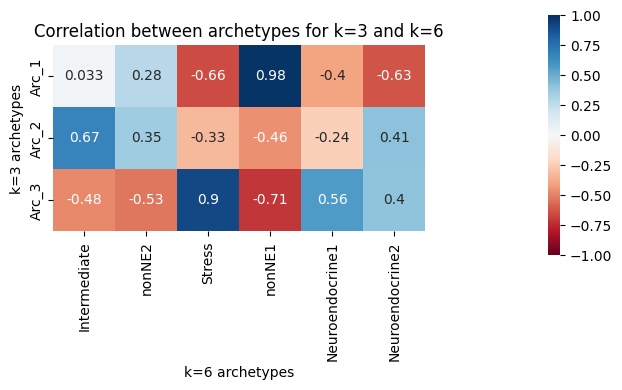

Optimal matching for k=3:
  Arc_1 (k=3) ↔ nonNE1 (k=6): corr = 0.982
  Arc_2 (k=3) ↔ Intermediate (k=6): corr = 0.668
  Arc_3 (k=3) ↔ Stress (k=6): corr = 0.900


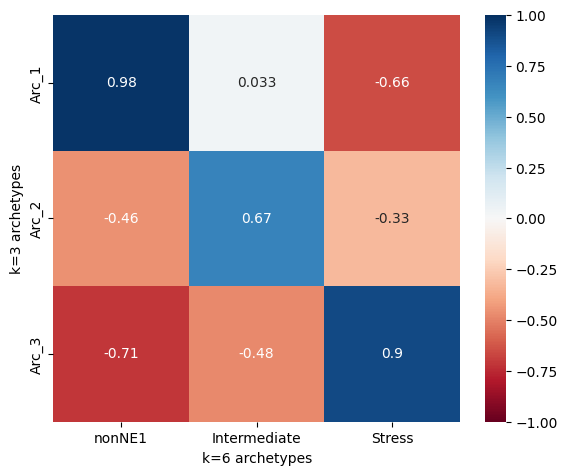

(4, 7) (6, 7)


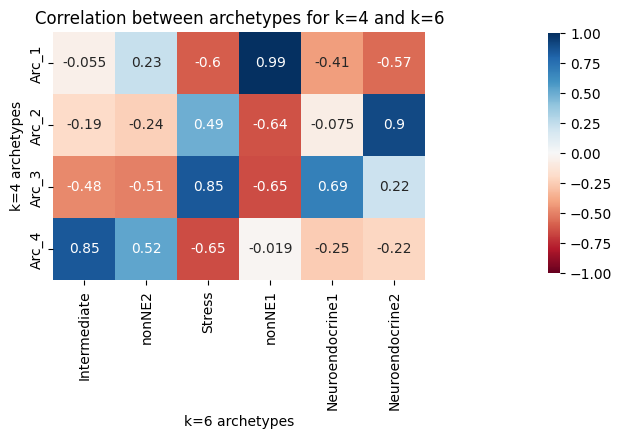

Optimal matching for k=4:
  Arc_1 (k=4) ↔ nonNE1 (k=6): corr = 0.993
  Arc_2 (k=4) ↔ Neuroendocrine2 (k=6): corr = 0.903
  Arc_3 (k=4) ↔ Stress (k=6): corr = 0.847
  Arc_4 (k=4) ↔ Intermediate (k=6): corr = 0.846


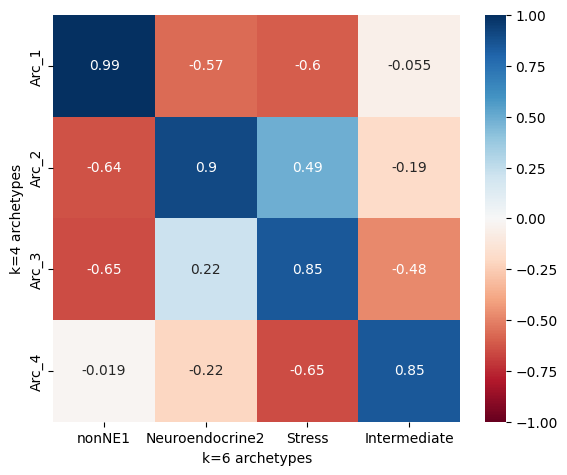

(5, 7) (6, 7)


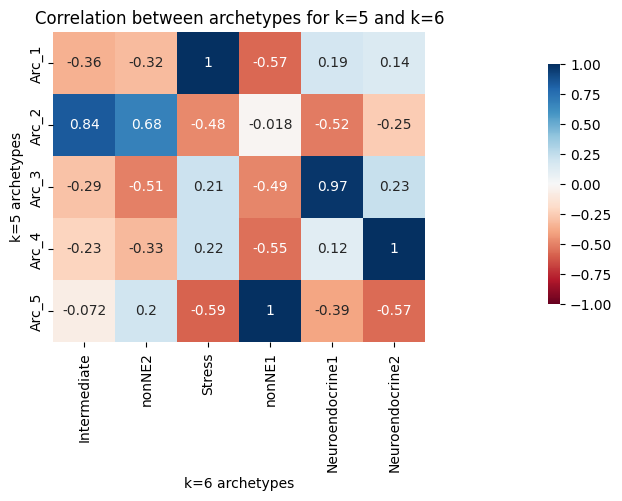

Optimal matching for k=5:
  Arc_1 (k=5) ↔ Stress (k=6): corr = 0.998
  Arc_2 (k=5) ↔ Intermediate (k=6): corr = 0.836
  Arc_3 (k=5) ↔ Neuroendocrine1 (k=6): corr = 0.971
  Arc_4 (k=5) ↔ Neuroendocrine2 (k=6): corr = 0.999
  Arc_5 (k=5) ↔ nonNE1 (k=6): corr = 0.996


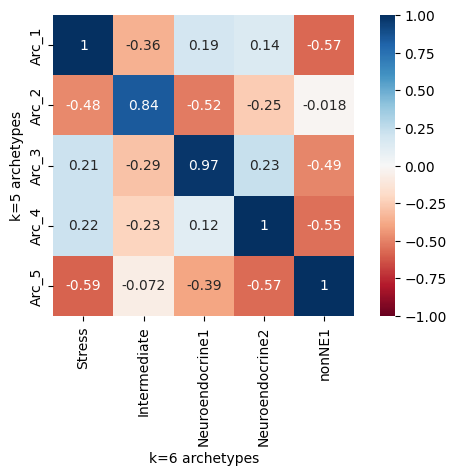

(6, 7) (6, 7)


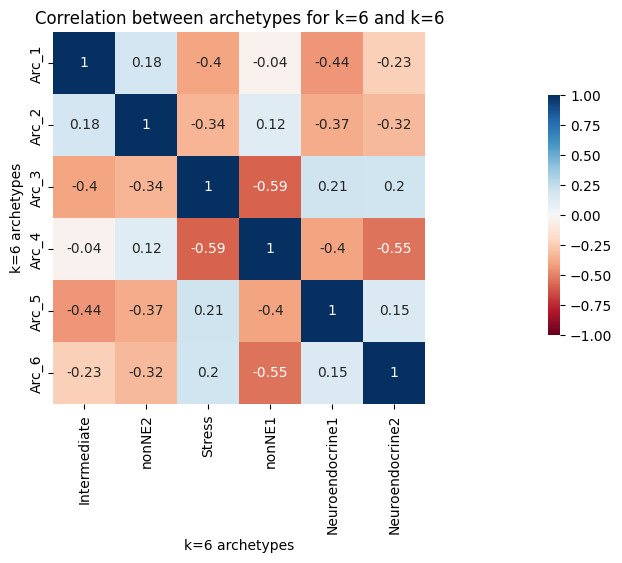

Optimal matching for k=6:
  Arc_1 (k=6) ↔ Intermediate (k=6): corr = 1.000
  Arc_2 (k=6) ↔ nonNE2 (k=6): corr = 1.000
  Arc_3 (k=6) ↔ Stress (k=6): corr = 1.000
  Arc_4 (k=6) ↔ nonNE1 (k=6): corr = 1.000
  Arc_5 (k=6) ↔ Neuroendocrine1 (k=6): corr = 1.000
  Arc_6 (k=6) ↔ Neuroendocrine2 (k=6): corr = 1.000


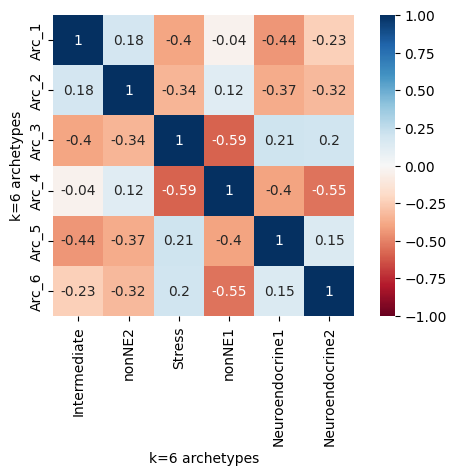

(7, 7) (6, 7)


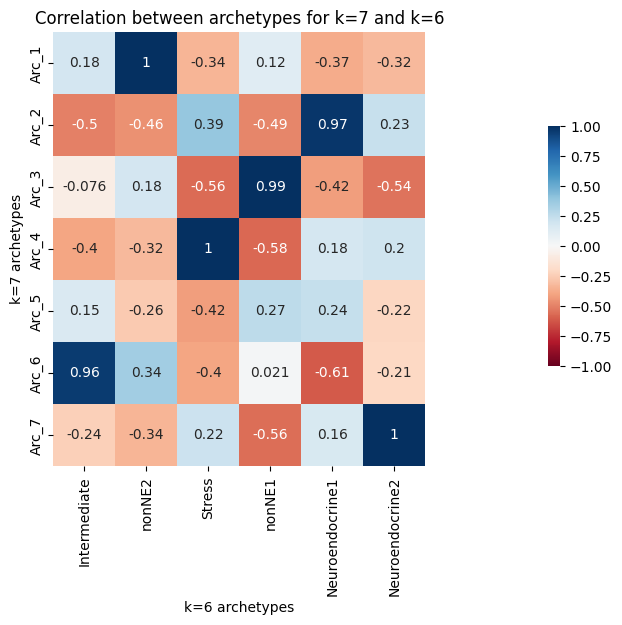

Optimal matching for k=7:
  Arc_1 (k=7) ↔ nonNE2 (k=6): corr = 1.000
  Arc_2 (k=7) ↔ Neuroendocrine1 (k=6): corr = 0.974
  Arc_3 (k=7) ↔ nonNE1 (k=6): corr = 0.994
  Arc_4 (k=7) ↔ Stress (k=6): corr = 0.999
  Arc_6 (k=7) ↔ Intermediate (k=6): corr = 0.955
  Arc_7 (k=7) ↔ Neuroendocrine2 (k=6): corr = 1.000


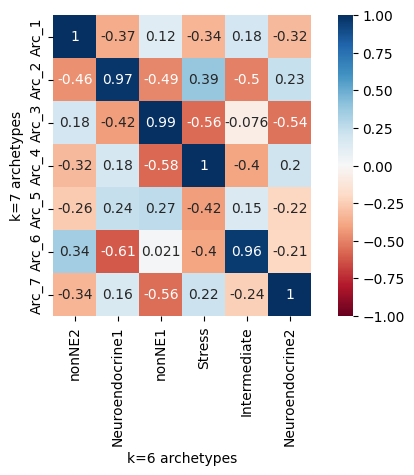

In [21]:

from scipy.optimize import linear_sum_assignment

#correlation between archetypes across different k
for i in range(3, 8):
    print(f"Correlation between archetypes for k={i} and k=6:")
    print(np.corrcoef(adata.uns[f'XC_{i}'], adata.uns[f'XC_6'])[:i, i:])

arc_6_labels = ['Intermediate', 'nonNE2', 'Stress', 'nonNE1', 'Neuroendocrine1', 'Neuroendocrine2']
for i in range(3, 8):
    plt.figure(figsize=(6,6))
    plt.title(f"Correlation between archetypes for k={i} and k=6")
    #show numbers on heatmap
    print(adata.uns[f'XC_{i}'].shape, adata.uns[f'XC_6'].shape)
    corr_mat = np.corrcoef(adata.uns[f'XC_{i}'], adata.uns[f'XC_6'])[:i, i:]
    sns.heatmap(corr_mat, 
                square=True,
                annot=True, cmap='RdBu', vmin=-1, vmax=1, xticklabels=arc_6_labels, yticklabels=[f'Arc_{x+1}' for x in range(i)])
    #make colorbar smaller
    cbar = plt.gcf().axes[-1]
    cbar.set_position([0.95, 0.3, 0.02, 0.4])
    plt.xlabel(f"k=6 archetypes")
    plt.ylabel(f"k={i} archetypes")
    plt.savefig(f'./figures/correlation_XC_arc_location_k_{i}_k_6_full_7PCs.png')

    plt.show()
    plt.close() 
    #reorder axes in corr_mat so that highest correlation in on diagonal

    # Find optimal matching (maximize correlation = minimize negative correlation)
    row_ind, col_ind = linear_sum_assignment(-corr_mat)

    # Reorder columns to align with rows
    corr_mat_reordered = corr_mat[:, col_ind]

    # Also reorder the labels
    arc_6_labels_reordered = [arc_6_labels[j] for j in col_ind]

    print(f"Optimal matching for k={i}:")
    for r, c in zip(row_ind, col_ind):
        print(f"  Arc_{r+1} (k={i}) ↔ {arc_6_labels[c]} (k=6): corr = {corr_mat[r, c]:.3f}")

    sns.heatmap(corr_mat_reordered, 
                square=True,
                annot=True, cmap='RdBu', vmin=-1, vmax=1, xticklabels=arc_6_labels_reordered, yticklabels=[f'Arc_{x+1}' for x in range(i)])
    #make colorbar smaller
    cbar = plt.gcf().axes[-1]
    cbar.set_position([0.95, 0.3, 0.02, 0.4])
    plt.xlabel(f"k=6 archetypes")
    plt.ylabel(f"k={i} archetypes")
    plt.tight_layout()
    plt.savefig(f'./figures/correlation_XC_arc_location_k_{i}_k_6_matched_7PCs.png')
    plt.show()